In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## Loading Dataset

In [102]:
df = pd.read_csv(r'insurance.csv')

## EDA

In [103]:
df.head(3)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523
2,28,male,33.00,3,no,southeast,4449.4620


In [104]:
df.shape

(1338, 7)

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [106]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [107]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [108]:
df.duplicated().sum()

np.int64(1)

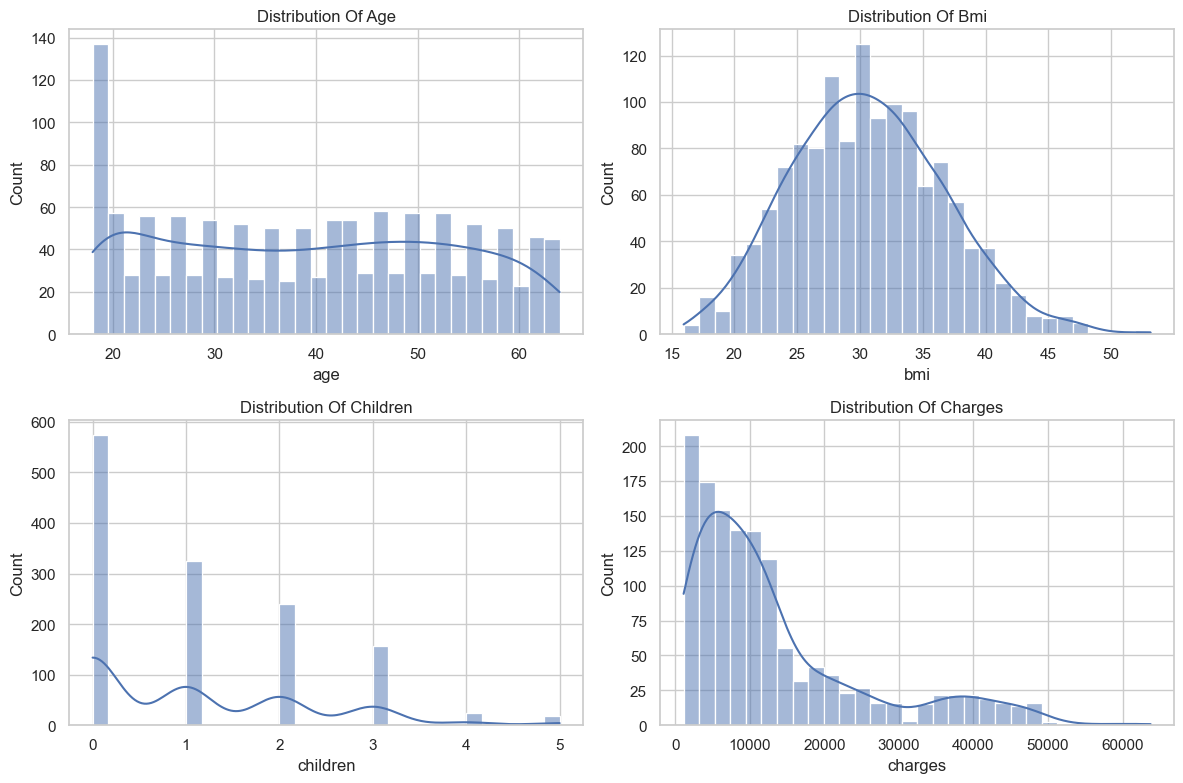

In [109]:
numeric_col = df.select_dtypes([int, float]).columns

sns.set_theme(style="whitegrid", palette="deep")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_col):
    sns.histplot(df[col], ax = axes[i], kde = True, bins = 30)
    axes[i].set_title(f'distribution of {col}'.title())

plt.tight_layout()

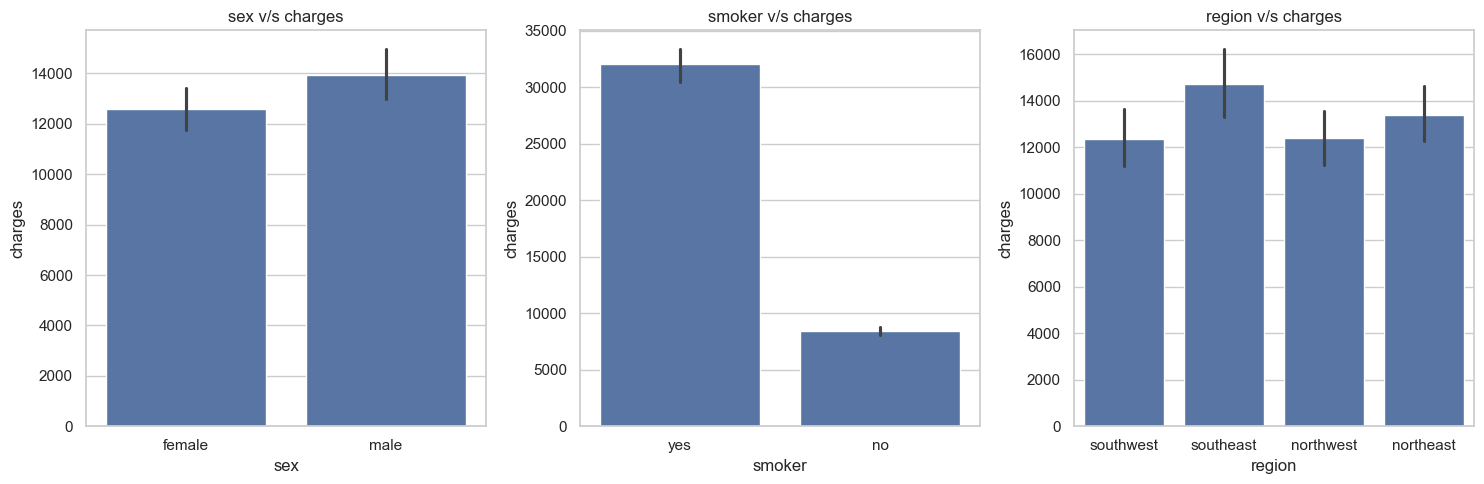

In [110]:
category_col = df.select_dtypes(object).columns

sns.set_theme(style="whitegrid", palette="deep")

fig, axes = plt.subplots(1, 3, figsize = (15, 5))
sns.set_palette('viridis')

for i, col in enumerate(category_col):
    sns.barplot(x = col, y = 'charges', data = df, ax = axes[i])
    axes[i].set_title(f'{col} v/s charges')

plt.tight_layout()
plt.show()

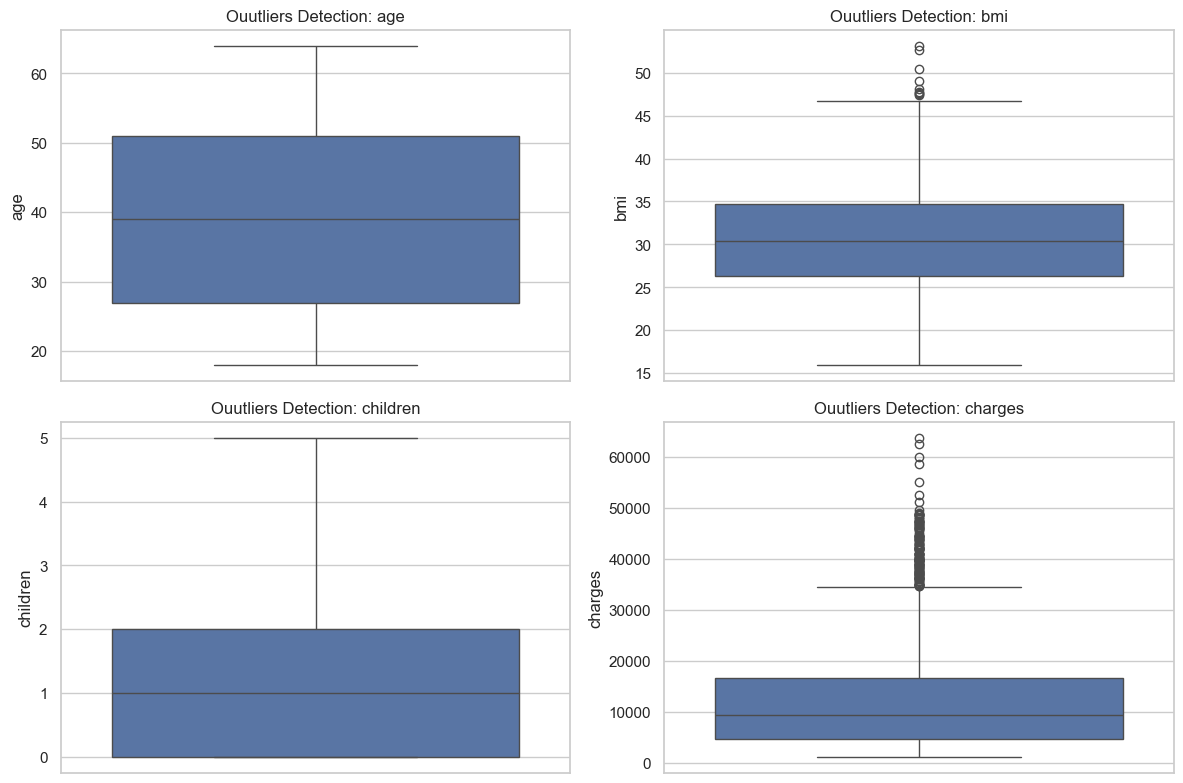

In [111]:
sns.set_theme(style="whitegrid", palette="deep")
fig, axes = plt.subplots(2, 2, figsize = (12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_col):
    sns.boxplot(df[col], ax = axes[i])
    axes[i].set_title(f'Ouutliers Detection: {col}')

plt.tight_layout()

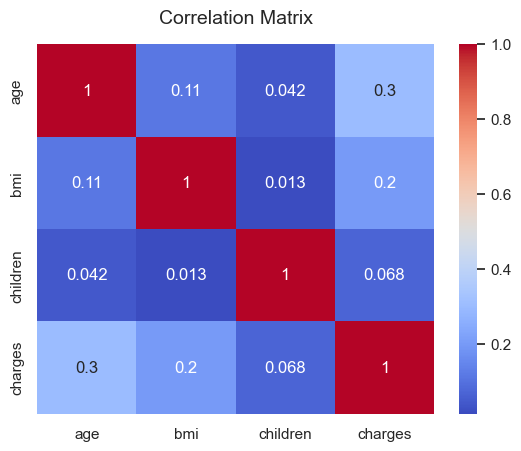

In [112]:
sns.heatmap(
    df.corr(numeric_only=True), 
    annot=True,
    cmap="coolwarm",  
)

plt.title("Correlation Matrix", fontsize=14, pad=15)
plt.show()

## Data Cleaning

In [113]:
df.drop_duplicates(inplace = True)

### Outliers Handling

In [114]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df['bmi'] = df['bmi'].clip(upper = upper_bound)

<Axes: ylabel='bmi'>

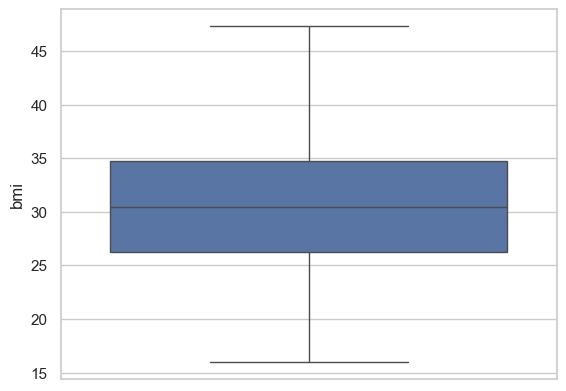

In [115]:
sns.boxplot(df['bmi'])

## Data Preprocessing

In [116]:
df['sex'].unique()

array(['female', 'male'], dtype=object)

In [117]:
df['sex'] = df['sex'].map({
    'female' : 0,
    'male' : 1
})

In [118]:
df = df.rename(columns={'sex': 'is_male'})

In [119]:
df.head()

,age,is_male,bmi,children,smoker,region,charges
0,19,0,27.900,0,yes,southwest,16884.92400
1,18,1,33.770,1,no,southeast,1725.55230
2,28,1,33.000,3,no,southeast,4449.46200
3,33,1,22.705,0,no,northwest,21984.47061
4,32,1,28.880,0,no,northwest,3866.85520


In [120]:
df['smoker'].unique()

array(['yes', 'no'], dtype=object)

In [121]:
df['smoker'] = df['smoker'].map({
    'no' : 0,
    'yes' : 1
})

In [122]:
df = df.rename(columns={'smoker': 'is_smoker'})

In [123]:
df.head(3)

,age,is_male,bmi,children,is_smoker,region,charges
0,19,0,27.90,0,1,southwest,16884.9240
1,18,1,33.77,1,0,southeast,1725.5523
2,28,1,33.00,3,0,southeast,4449.4620


In [124]:
df = pd.get_dummies(df, columns = ['region'], drop_first = True, dtype = int)

In [126]:
df.head()

,age,is_male,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


## Features Engineering 

In [127]:
df['is_obese'] = (df['bmi'] >= 30).astype(int)

In [129]:
df['has_children'] = (df['children'] > 0).astype(int)

In [131]:
df['obese_smoker'] = ((df['bmi'] >= 30) & (df['is_smoker'] == 1)).astype(int)

In [132]:
df.head()

,age,is_male,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,is_obese,has_children,obese_smoker
0,19,0,27.900,0,1,16884.92400,0,0,1,0,0,0
1,18,1,33.770,1,0,1725.55230,0,1,0,1,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0,1,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0,0,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0,0,0,0


## Train Test Split

In [134]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['charges'])
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Standard Scaling

In [136]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [139]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

X_train_scaled.head(3)

,age,is_male,bmi,children,is_smoker,region_northwest,region_southeast,region_southwest,is_obese,has_children,obese_smoker
0,-1.157680,0.971409,-1.002462,-0.907908,-0.500292,-0.572669,-0.605812,-0.57411,-1.035232,-1.155016,-0.333507
1,-1.300619,0.971409,-0.796635,0.766904,-0.500292,-0.572669,-0.605812,-0.57411,-1.035232,0.865789,-0.333507
2,0.914926,-1.029432,1.166632,0.766904,-0.500292,1.746208,-0.605812,-0.57411,0.965967,0.865789,-0.333507


##  Features Selection

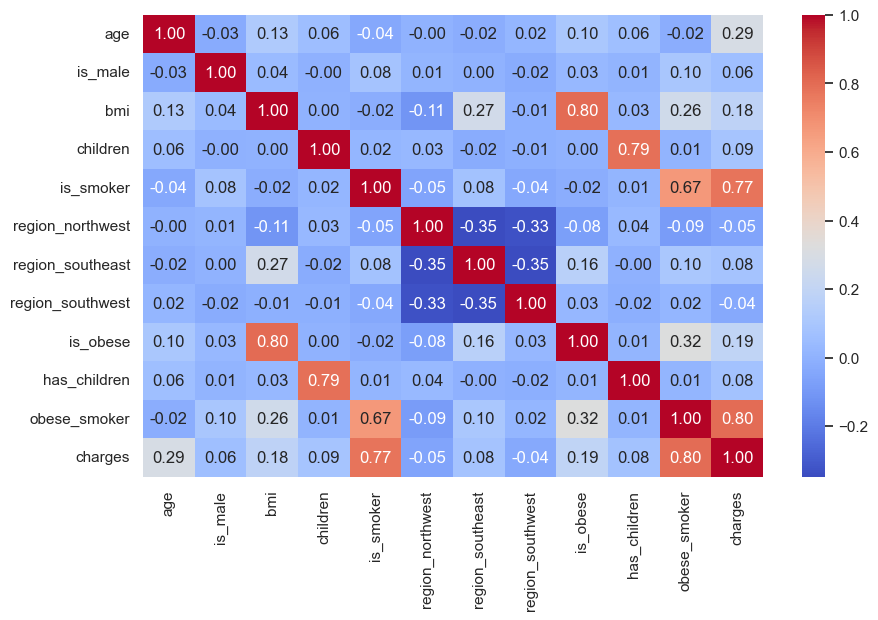

In [140]:
train_data = X_train_scaled.copy()
train_data['charges'] = y_train.values

plt.figure(figsize=(10, 6))
sns.heatmap(train_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [144]:
columns_to_drop = ['has_children', 'is_obese', 'region_northwest', 'is_male', 'region_southeast', 'region_southwest']

X_train_final = X_train_scaled.drop(columns = columns_to_drop)
X_test_final = X_test_scaled.drop(columns = columns_to_drop)

##  Model Training

In [157]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

lr_model = LinearRegression()

lr_model.fit(X_train_final, y_train)

y_pred = lr_model.predict(X_test_final)

r2 = r2_score(y_test, y_pred)
r2 = r2 * 100
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Model R2 Score (Accuracy): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Model R2 Score (Accuracy): 90.3505
Mean Absolute Error (MAE): 2367.65
Root Mean Squared Error (RMSE): 4210.89


## Feature Coefficients

In [146]:
coefficients = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coefficients)
print(f"\nIntercept: {lr_model.intercept_:.2f}")

        Feature  Coefficient
4  obese_smoker  5793.679251
3     is_smoker  5330.981077
0           age  3636.142154
2      children   675.694474
1           bmi   240.405662

Intercept: 13030.20


## Model Saving

In [151]:
import joblib

joblib.dump(lr_model, 'medical_insurance_lr_model.pkl')

joblib.dump(scaler, 'insurance_scaler.pkl')

print("Model is saved successfully 🎉")


Model is saved successfully 🎉


## Conclusion 

---

## 🎯 Conclusion & Key Takeaways

This project demonstrates how strategic **Feature Engineering** can significantly boost a model's predictive power over complex algorithms. 

### Key Discoveries:
1. **Domain Knowledge is King:** Creating the `obese_smoker` interaction feature based on real-world medical insurance risks was the turning point. It allowed a simple, interpretable model like Linear Regression to outperform a more complex, non-linear model like Random Forest.
2. **Simplicity Wins:** By dropping low-impact and highly correlated columns (`is_male`, `regions`, `is_obese`), we made the model cleaner, reduced the mean absolute error (MAE), and built a system that relies strictly on objective health risks rather than demographic biases.
3. **Data Leakage Prevention:** By properly splitting the dataset before applying `StandardScaler`, we ensured that our evaluation metrics reflect true performance on completely unseen data.

Ultimately, this project highlights that **understanding the data and the business domain** is often far more valuable than blindly tuning hyperparameters or using heavy algorithms.
